# Lab: Intoroduction to Pytorch and ANN

### Outline
1. Basic pytorch operations
2. Simple linear regression using pytorch
3. Logistic regression using pythorch
4. Building a simple ANN using pytorch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F


## Basic PyTorch (tensor operations)

PyTorch tensor operations are essentially the same as those on Numpy arrays. Since PyTorch is specifically geared towards deep learning, there are nice functionalities such as GPU support and automatic gradient calculations. 

This section is loosely based on [this tutorial](https://github.com/varal7/ml-tutorial).

**Note:** A refresher for scope of varables in python will be useful and can be found [here](https://www.w3schools.com/python/python_scope.asp)

Below are some basic tensor operations

In [3]:
# some ones
print(torch.ones(2, 2))

# some zeros
print(torch.zeros(2, 2))

# random values from the unit normal distribution
print(torch.randn(2, 2))

tensor([[1., 1.],
        [1., 1.]])
tensor([[0., 0.],
        [0., 0.]])
tensor([[-0.5053,  1.0279],
        [-0.9181, -0.2783]])


In [4]:
# Converting between PyTorch tensors and NumPy ndarrays is very simple. 

torch_tensor = torch.randn(5, 5)

np_array = torch_tensor.numpy()

print(type(np_array), type(torch_tensor))

back_to_torch = torch.from_numpy(np_array)

<class 'numpy.ndarray'> <class 'torch.Tensor'>


There are far too many tensor operations for us to cover here, so please check out the list over at [the official pytorch tensors documentation](https://pytorch.org/docs/stable/tensors.html)

We will cover a few basic useful ones below.

In [5]:
# create two tensors for use
a = torch.randn(5, 5)
b = torch.randn(5, 5)

print(a)

tensor([[ 2.1357, -0.8214,  1.3886,  0.1678, -0.7173],
        [ 1.3317, -1.6932, -0.1683,  0.9072, -0.1720],
        [ 0.0551,  0.4637, -1.6033,  1.5098,  0.7879],
        [ 0.6760,  0.8551,  0.5422,  0.1638,  1.8212],
        [ 0.7528, -0.7999, -0.6441,  0.4181,  0.6081]])


In [6]:
# slicing rows and columns etc. work just like in numpy
first_row = a[0, :]
first_col = a[:, 0]
# subarray = a[2:4, 2:4]

print(first_col)

tensor([2.1357, 1.3317, 0.0551, 0.6760, 0.7528])


In [7]:
# indexing by i, j
print( torch_tensor)
print(torch_tensor[2, 2])

# the element is returned as another tensor. to get the actual value:
print(torch_tensor[2, 2].item())

tensor([[-0.7730, -0.6911, -0.5662,  1.9400, -0.9046],
        [-0.3721,  1.2399,  0.7966, -2.5540,  0.0484],
        [ 0.2328, -0.1904, -1.5691,  2.0648, -1.0158],
        [ 1.4999, -0.3766,  0.6059, -0.0138, -0.2665],
        [-0.0089, -0.3803, -0.4088,  0.0605,  0.5148]])
tensor(-1.5691)
-1.569076418876648


In [8]:
# addition
c = a + b

# elementwise multiplication 
c = a * b

# matrix multiplication
c = a.mm(b)

# multiplication between matrix and vector (try doing this with mm)
c = a.matmul(b[:, 0])

# shorthand version
d = a @ b[:, 0]

# Linear regression from scratch


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Linear_regression.svg/1200px-Linear_regression.svg.png" alt="linear regression" width="550"/>

Now that we know our way around tensors and some basic operations, we can try our hands at coding a linear regression model from scratch. Since we'll be using mean squared error (MSE) as the loss function, this is essentially the same as the least-squares regression that many of you would have encountered in statistics before coming to university. 

For least-squares regression, given some data that show a (linear) correlation between the dependent variable and the independent variable, we want to find an equation $y = mx + c$ that captures the correlation between the two variables. Here $m$ is the slope and $b$ is the intercept. 

Now suppose that the independent variables are represented by a $\textrm{N}\times \textrm{D} $  matrix $X = [ \mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_N ]^T$, with $\mathbf{x}_1 = [x_1,x_2,...,x_D]$

and, we have $\textrm{L}$ dependent variables, which can be written as a $\textrm{N}\times \textrm{L} $ matrix $Y $. 

Then following the same principles as above we can find a ${\textrm{L} \times \textrm{D}}$ weight  matrix $W $ and a $ \textrm{L} \times \textrm{1} $ "intercept" (bias) vector $B$ such that 

$$ Y = X W^T+  I B^T  $$

where $I$ is $\textrm{N} \times 1 $ matrix of ones 

#### How do we find such a matrix $W$ and a vector $B$? 

The answer is simple - we start with random numbers and use **gradient descent** to iteratively nudge the numbers in the desired direction. 

We first need to define a loss function, though. This is something that calculates a single numerical value that measures the performance of the model. The better our predictions, the lower the loss. This is just a generalisation of the total square of errors in least-square regression. 

Once we have a loss, we will be able to compute the direction we need to go in order to decrease the loss. This involves some fairly complicated calculus, but luckily pytorch has ```torch.autograd``` (automatic differentiation) built-in. 

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif" alt="gradient descent" width="300">

<!-- ![Gradient descent](https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif) -->

Let's try it out with an example problem of predicting fruit yields based on the temperature, rainfall, and humidity of different regions. For simplicity we will only predict the amount of apples produced, but in the exercise you will get to extend this model to cover both fruits. 

adapted from https://www.kaggle.com/aakashns/pytorch-basics-linear-regression-from-scratch

In [9]:
# data preparation

data = pd.DataFrame(columns = ["region", "temperature", "rainfall", "humidity", "apples", "oranges"])
for i in range(5):
    data.loc[i, "region"] = "ABCDE"[i]

inputs = np.array([[73, 67, 43], 
                   [91, 88, 64], 
                   [87, 134, 58], 
                   [102, 43, 37], 
                   [69, 96, 70]],
                  dtype = "float32"
)
targets = np.array([[56, 70], 
                    [81, 101], 
                    [119, 133], 
                    [22, 37], 
                    [103, 119]],
                   dtype = "float32"
)

data[data.columns[1:]] = np.concatenate((inputs, targets), axis = 1)

In [10]:
data

,region,temperature,rainfall,humidity,apples,oranges
0,A,73.0,67.0,43.0,56.0,70.0
1,B,91.0,88.0,64.0,81.0,101.0
2,C,87.0,134.0,58.0,119.0,133.0
3,D,102.0,43.0,37.0,22.0,37.0
4,E,69.0,96.0,70.0,103.0,119.0


In [11]:
# convert inputs and targets to torch tensors

inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets[:, 0])

In [12]:
# initialise the weight and bias matrices
# since we will be using the pytorch autograd, we set requires_grad = True

w = torch.randn(1,3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

print(w)
print(b)

tensor([[-2.0695, -2.4443,  0.5954]], requires_grad=True)
tensor([-1.1074], requires_grad=True)


In [13]:
# define a simple regression model

def model(x):
    return x@w.t()  + b

In [14]:
# try the model by doing some predictions, and compare with the targets
# since the weights are random, it likely won't perform very well

preds = model(inputs)

print(preds.view(1, -1))
print(targets)

tensor([[-290.3463, -366.4246, -474.1574, -295.2689, -336.8791]],
       grad_fn=<ViewBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])


In [15]:
# define a loss function.
# since we are comparing numbers, we can use the mean squared error (MSE)

def mse(y1, y2):
    diff = y1 - y2
    return torch.sum(diff * diff) / diff.numel()

In [16]:
# calculate the loss

loss = mse(preds, targets)
print(loss)

# compute the gradients automatically using pytorch
loss.backward()

tensor(189541.6562, grad_fn=<DivBackward0>)


In [17]:
# the gradients are actually stored in the weights themselves
print(w)
print(w.grad)

# similarly for the bias
print(b)
print(b.grad)

tensor([[-2.0695, -2.4443,  0.5954]], requires_grad=True)
tensor([[-72524.0391, -77154.4844, -47468.0312]])
tensor([-1.1074], requires_grad=True)
tensor([-857.6305])


In [18]:
# do one back propagation step

# choose a learning rate (scales the gradient)
lr = 1e-5

# no_grad() tells pytorch not to track the gradients, 
# as it is not necessary for the weight update
with torch.no_grad():
    w -= w.grad * lr
    b -= b.grad * lr

    w.grad.zero_()
    b.grad.zero_()

We usually choose a small learning rate to avoid situations where the stride is too wide, making the weights miss the minimum. 


<img src="./images/learning_rate.gif" width="600"/>



In [19]:
# the weight and bias have now been updated
# and the model should have a lower loss
print(w)
print(b)
preds = model(inputs)
loss = mse(preds, targets)

print(preds.view(1, -1))
print(targets)

print(loss)

tensor([[-1.3442, -1.6728,  1.0700]], requires_grad=True)
tensor([-1.0989], requires_grad=True)
tensor([[-165.2904, -202.1437, -280.1345, -170.5462, -179.5330]],
       grad_fn=<ViewBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])
tensor(78993.7969, grad_fn=<DivBackward0>)


### Putting it all together and train for multiple epochs

In machine/deep learning language, training for one epoch means that the model has seen all the available training data one time. In almost all cases multiple epochs is needed for optimal performance - let's try training for 100 epochs and plot the losses to see how our model turns out. 

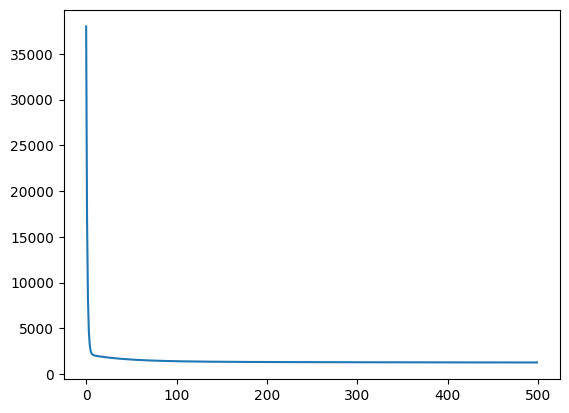

In [20]:
# initiate the parameters
w = torch.randn(1, 3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

# choose a number of epochs
num_epochs = 500
lr = 1e-5

# store the losses for plotting
losses_storage = np.zeros(num_epochs)

for i in range(num_epochs):
    preds = model(inputs)
    loss = mse(preds, targets)
    loss.backward()
    
    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr
        w.grad.zero_()
        b.grad.zero_()
        
    losses_storage[i] = loss.item()

plt.plot(losses_storage)

In [21]:
# compare our outputs to actual values
print(preds.view(1, 5).round())
print(targets)

tensor([[64., 81., 85., 80., 67.]], grad_fn=<RoundBackward0>)
tensor([ 56.,  81., 119.,  22., 103.])


We can see that the model/network has been saturated (it cannot improve any more) as the training loss has leveled off, but the final predictions aren't great. This could be due to several reasons, for example

* this is a very simple model/network with only a few parameters, so it is not very powerful. 
* the task is quite difficult as we are trying to predict exact numbers
* the weights may be stuck at a local minimum 


<img src="https://bdtechtalks.com/wp-content/uploads/2020/04/gradient-descent-local-minima.png" width="500"/>

To illustrate the effect of local minima, I have some code below that will train 100 models, each for 100 epochs (hopefully enough for saturation). The histogram shows the lowest loss achieved lies around 1300. Though this seems to be the most common final loss, we did have a sizeable number of models bottoming out at 1400+ which suggest that they failed to reach the global minima. 

There are more complex versions of the gradient descent algorithm that attempt to deal with problems like this. PyTorch has a great number of optimizers built-in, and we will briefly touch on them in the next session. 

In [22]:
# feel free to lower the numbers if this takes a long time to run
# we just need a large enough sample size - say 20

num_repeats = 100
final_losses = []

# choose a number of epochs
num_epochs = 100
lr = 1e-5

for _ in range(100):
    # initiate the parameters
    w = torch.randn(1, 3, requires_grad = True)
    b = torch.randn(1, requires_grad = True)

    for i in range(num_epochs):
        preds = model(inputs)
        loss = mse(preds, targets)
        loss.backward()

        with torch.no_grad():
            w -= w.grad * lr
            b -= b.grad * lr
            w.grad.zero_()
            b.grad.zero_()

    final_losses.append(loss.item())

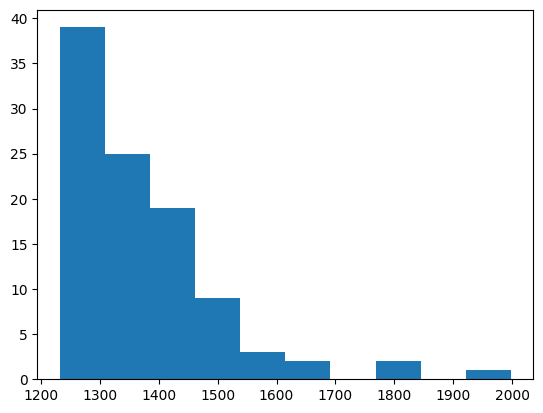

In [23]:
plt.hist(final_losses);

# Convert to classification

Classification follows the same principles - we still have some input data, some weights and biases that we train using gradient descent which give us some outputs. Except this time by definition the output/target is categorical instead of numerical. 

Let us modify the dataset to predict whether apple production will be >100 or <=100. This will be a simple binary classification.

In [24]:
# transform the target values into a binary variable 
print(targets)

labels = targets > 100
labels = labels.long()
print(labels)

tensor([ 56.,  81., 119.,  22., 103.])
tensor([0, 0, 1, 0, 1])


## Logistic regression model
We modify our linear regression model to perform classification using logistic regression. We do this by adding a non-linearity in the form of a sigmoid function. The purpose of this is to squish the outputs of the model towards either 0 (negative) or 1 (positive). These are also essential for building networks with more layers, since stacking linear transformations on top of each other just results in a single linear transformation. 

![sigmoid](https://qph.fs.quoracdn.net/main-qimg-6b67bea3311c3429bfb34b6b1737fe0c)

In [25]:
# we add a non-linearity in the form of a sigmoid

w = torch.randn(1, 3, requires_grad = True)
b = torch.randn(1, requires_grad = True)

def classification_model(x):
    # calculate as before
    h =  w @x.t()+ b
 
    # add on a sigmoid activation function
    y = 1 / (1 + torch.exp(-h))

    return y

# use binary cross entropy as our loss function
# we cheat and use the built in binary cross entropy implementation
# this will be covered more in the next session
import torch.nn as nn
loss_fn = nn.BCELoss()

In [26]:
# train the model for some epochs
# note that the inputs have been scaled down 
# so that the outputs of the sigmoid does not blow up

lr = 0.5
num_epochs = 2000
losses_storage = np.zeros(num_epochs)

for i in range(num_epochs):
    predictions = classification_model(inputs/100)
    loss = loss_fn(predictions.squeeze(), labels.float())
    loss.backward()
    
    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr
        w.grad.zero_()
        b.grad.zero_()
    
    losses_storage[i] = loss.item()
    

tensor([0., 0., 1., 0., 1.], grad_fn=<SqueezeBackward0>)
tensor([0, 0, 1, 0, 1])


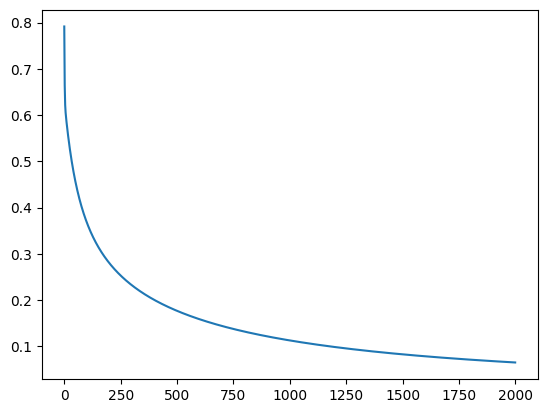

In [27]:
plt.plot(losses_storage)

print(predictions.round().squeeze())
print(labels)

# From logistic regression to a simple ANN


The dataset we use is the **MNIST** hand-written digits dataset. This consists of black-and-white images of hand-drawn digits between 0 and 9. It is often referred to as the "hello world" of machine learning. 

In [28]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import torchvision
from torch import nn

First we load the data and split it into train/valid sets. As the names suggest, the train set is used for training the model, and the validation set is used to quantify model performance. In the real world we care about how our model performs on unseen data, so the validation set is not used during training. 

In [29]:
# create directory and download MNIST if not already present
from pathlib import Path
import requests
import pickle
import gzip

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"
FILENAME = "mnist.pkl.gz"

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

C:\Users\babu_m\AppData\Local\Temp\ipykernel_13068\2085829542.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")



The training set contains 40,000 samples and the validation/test set contains 10,000 for an 80/20 split.

Note that the words "validation" and "test" are used interchangeably here, but strictly speaking they refer to different things. [This website](https://machinelearningmastery.com/difference-test-validation-datasets/) is a good starting point if you're unsure about the difference.

Let's plot one example to see what the data actually looks like. 

true label:  5


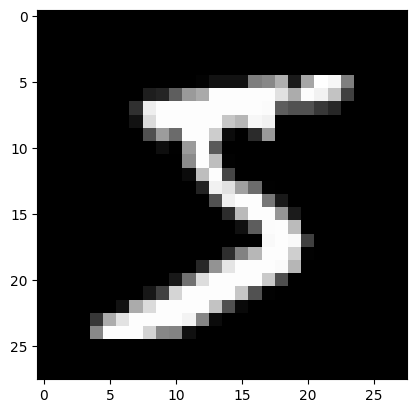

In [30]:
# plot one example 
plt.imshow(x_train[0].reshape((28, 28)), cmap = "gray");
print("true label: ", y_train[0].item())

In [31]:
# before we can work with them, they need to be converted
# into torch.tensors

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid))

# Obtain the number of samples and features
n, c = x_train.shape

print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


## Using ```nn.Module``` 

Instead of defining all the mathematical operations ourself, like we did in tutorial 1 as

```
def classification_model(x):
    # calculate as before
    h =  w @x.t()+ b
 
    # add on a sigmoid activation function
    y = 1 / (1 + torch.exp(-h))

    return y
```

Let's define a `model` based on the ```nn.Module``` class. This is the base class for all neural network modules ([official documentation](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)), so anything we define on top of this will automatically inherit all the nice built-in functions. 

Two very useful functions are 
1. ```model.eval()``` i.e. ```nn.Module.eval() ```
2. ```model.forward()```

We can call ```model.eval()``` to put the model into evaluation mode and automatically freeze all of the weights. 

We will first build our model and incrementally add inbuilt `torch.nn` functions and modules

First, we use ```nn.Parameter``` to define the weights and biases. This tells the model that these are its parameters (`requires_grad` is set to `True` by default) - this becomes useful when doing back propagation, as we can iterate through all the parameters instead of needing to explicitly update each one. 


In [32]:
class Mnist_Logistic(nn.Module):
    # __init__ contains the setup/architecture of the model
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(784, 10) / np.sqrt(784))# requires_grad is set to true by default
        self.bias = nn.Parameter(torch.zeros(10))
        
    # forward tells the model what to compute when we feed inputs in
    def forward(self, x):
        return x @ self.weights + self.bias

Since the model is now defined as a class, we need to instantiate the model. 

Let's choose the cross entropy from ```torch.nn.functional``` (F). This is a generalised version of binary cross entropy so that it can deal with multiple output variables.

>*``torch.nn.functional`` contains all the operations or building blocks we might need when we construct our own networks - things like convolution or pooling. All details in Pytorch documentation [here](https://pytorch.org/docs/stable/nn.functional.html#)*

In [33]:
model = Mnist_Logistic()
loss_fn = F.cross_entropy

In [34]:
# do one gradient calculation as before
loss = loss_fn(model(x_train), y_train)
loss.backward()

This is how we updated the weights before, but for more complex models this gets cumbersome as we would need to update each weight individually. 

``` with torch.no_grad():
    weights -= weights.grad * lr
    bias -= bias.grad * lr
    weights.grad.zero_()
    bias.grad.zero_() ```
    
With the help of `nn.Parameter`, we can now iterate through all the parameters (weights and biases etc.) to update them without the need to explicitly write out each one individually. 

In [35]:
lr = 0.5

with torch.no_grad():
    for p in model.parameters(): p -= p.grad * lr
    model.zero_grad()

Remember that the training set contains 40,000 samples and the validation/test set contains 10,000 for an 80/20 split. Since these are fairly large numbers, we might run into memory problems if we try to load all of them at once. 

We solve this by training and testing in small batches of predetermined ```batch_size```. In general, the larger the batch size, the more representative each batch will be for the entire population, and therefore the more similar batches will be to each other, allowing a smoother training process. 

This is one of the many hyperparameters we need to give the model. Other essential ones include the learning rate and the number of epochs to train for, which we covered in the previous session. 

Choosing what hyperparameters to use is more of an art than an exact science, though you will naturally get a grasp on what to use as you gain more experience. 

A training loop now looks like this - we have wrapped it inside the ```fit()``` function to be used later.

In [36]:
# define some hyperparameters to tell the model 
lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []

model = Mnist_Logistic()
loss_fn = F.cross_entropy

def fit():

    for epoch in range(num_epochs):
        for i in range((train_size - 1) // batch_size + 1):   
            start_i = i * batch_size
            end_i = start_i + batch_size
            x_batch = x_train[start_i:end_i]
            y_batch = y_train[start_i:end_i]
            
            
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)

            loss.backward()
            with torch.no_grad():
                for p in model.parameters():
                    p -= p.grad * lr
                model.zero_grad()
            losses_storage.append(loss.item())

fit()

**Task:** The process of loading data and splitting it into batches can be further siplified using [Dataset](https://pytorch.org/tutorials/beginner/nn_tutorial.html#refactor-using-dataset) and 
[DataLoader](https://pytorch.org/tutorials/beginner/nn_tutorial.html#refactor-using-dataloader), explore them.

## Using nn.Linear

```nn.Linear``` gives us a fully connected layer (each input neuron is connected to each output neuron, where each neuron is just a number) which is the basic building block of artificial neural networks (ANNs). Below we have defined an ANN with a single layer going straight from inputs to outputs to use for MNIST classification. 

![MNIST ANN](https://ml4a.github.io/images/figures/mnist_1layer.png)

In [37]:
class Mnist_Logistic(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features = 784, 
            out_features = 10
        )
        
    def forward(self, x):
        return self.linear(x) # return the un-normalised preactivations as required by cross entropy loss function. 

> Aside on terminology:

Output of **nn.Linear**: this is the raw affine transform

$z = Wx + b$

It is just a weighted sum plus bias.

**Preactivation**: a general name for the value before applying a nonlinearity (e.g., ReLU, sigmoid, softmax).
So for a linear layer followed by activation, the preactivation is exactly the nn.Linear output.

**Logit**: usually refers to the final layer preactivation used for classification.

**Multi-class**: logits are the class scores before softmax.
**Binary**: a single logit is the score before sigmoid.

So, nn.Linear output = preactivation, and when that preactivation is at the classifier head, it is called logits. 

In [38]:
model = Mnist_Logistic()
print(loss_fn(model(x_train), y_train))

tensor(2.3507, grad_fn=<NllLossBackward0>)


In [39]:
lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []

fit()

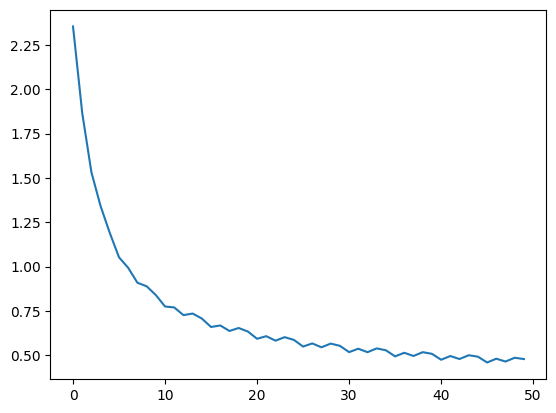

In [40]:
plt.plot(losses_storage)

As the loss levels off, it starts to fluctuate. This indicates that the model is overfitting - it is learning the noise/small deviations that are naturally present within the data. This is of course particular to each individual sample and each batch of samples. The fluctuation is caused by different batches having different quirks and pulling the model weights in different directions. 

In general we want to stop training when the training loss shows signs of overfitting (fluctuation) and the validation loss stops improving, signalling that the model has been saturated. 

### Optimizers

Optimizers exist so we do not have to manually update the parameter/weights and pytorch has the popular ones already implemented. This is especially useful when we want to use something more complex than standard gradient descent, e.g. stochastic gradient descent (SGD), RMSprop, Adam, etc... [Refer here](https://ruder.io/optimizing-gradient-descent/index.html) for an overview by Sebastian Ruder. List of available algorithms is [here](https://pytorch.org/docs/stable/optim.html#algorithms).


In [41]:
from torch import optim

we can use ``optim`` to replace the previously manually coded gradient update

``with torch.no_grad():
    for p in model.parameters(): p -= p.grad * lr
    model.zero_grad()
``

In [42]:
# we'll be using SGD for this example

model = Mnist_Logistic()
opt = optim.SGD(model.parameters(), lr=lr)

print(loss_fn(model(x_train), y_train))

tensor(2.2831, grad_fn=<NllLossBackward0>)


In [43]:
# run model

lr = 0.5
num_epochs = 10
train_size = n
batch_size = 10000
losses_storage = []


for epoch in range(num_epochs):
    for i in range((train_size - 1) // batch_size + 1):
        start_i = i * batch_size
        end_i = start_i + batch_size
        x_batch = x_train[start_i:end_i]
        y_batch = y_train[start_i:end_i]
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        # this is the only difference
        opt.step()
        opt.zero_grad()
        
        losses_storage.append(loss.item())

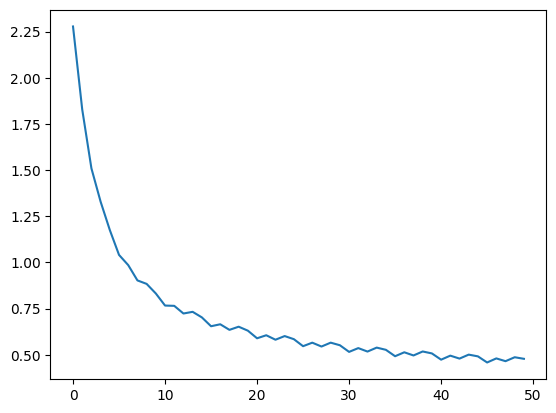

In [44]:
plt.plot(losses_storage)

# Additional resources / references

basic pytorch/tensors: https://github.com/varal7/ml-tutorial

3Blue1Brown neural network series on youtube: https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

kaggle regression tutorial: https://www.kaggle.com/aakashns/pytorch-basics-linear-regression-from-scratch